# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
PARA USERS:
city (11.73%): investigaría la causa de los valores faltantes. Dependiendo del análisis, podría imputarse (por ejemplo, con la ciudad más frecuente o usando información relacionada) o mantenerse como nulo.

churn_date (88.35%): aunque tiene un porcentaje muy alto de valores faltantes, no la eliminaría sin antes comprender su significado. En bases de datos de telecomunicaciones es habitual que esta columna sea nula para los clientes que no han cancelado el servicio. En ese caso, los NaN son esperados y deben conservarse.

PARA USAGE
date (0.02%): presenta una cantidad mínima de valores faltantes. Revisaría esos registros y, si no es posible recuperar la fecha, los eliminaría debido a que representan una fracción insignificante del conjunto de datos.

duration (9.64%): investigaría si los valores nulos corresponden a registros que no son llamadas. Si es así, los conservaría porque tienen un significado válido.

length (7.82%): verificaría si los valores nulos corresponden a registros que no son mensajes. Si esto se confirma, mantendría los valores nulos, ya que describen correctamente la ausencia de longitud para ese tipo de evento.

En este conjunto de datos es importante analizar la relación entre type, duration y length antes de imputar valores. Si los nulos dependen del tipo de actividad (llamada, mensaje o internet), forman parte de la estructura de los datos y no representan un problema de calidad.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users

- La columna `user_id  aparece en 0, significa que no hay valores nulos
- La columna `age` aparece en 0, se considera que  no hay valores nulos

In [13]:
# explorar columnas numéricas de usage

- Las columnas `id` y `user_id`aparecen en 0, es decir, no hay valores invalidos
- Las columnas 'date': 50 valores nulos,por lo que se recomienda revisar esos registros y eliminarlos si no es posible recuperar la información. Con respecto a 'duration': 22 076 valores nulos y 'length': 17 896 valores nulos,antes de realizar cualquier imputación es necesario verificar su relación con la variable type. Dado que estas variables probablemente solo aplican a llamadas y mensajes, respectivamente, es esperable que los valores nulos representen la ausencia de esa característica y, por tanto, deban conservarse.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


- La columna `city` Presenta 469 valores nulos (11.73%). Además de los nulos, conviene revisar si existen ciudades duplicadas por diferencias de escritura (por ejemplo, "New York" y "new york", espacios adicionales, abreviaturas, etc.).Es necesario investigar la causa de los valores nulos antes de decidir si imputarlos o conservarlos como nulos.
- La columna `plan` no presenta valores nulos, se verificaran cuáles son los planes disponibles mas adelante.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene dos categorías válidas: text y call, no se observan errores de escritura, ni valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, aparece registro 2026, es registro imposible porque los datos estan hasta 2024,este valor es inconsistente y probablemente corresponde a un error en el registro o la captura de la fecha. Se recomienda localizar ese registro, verificar si se trata de un error tipográfico (por ejemplo, una fecha que debía pertenecer a 2024) y corregirlo si existe información que lo respalde. En caso contrario, el registro debería excluirse del análisis para evitar sesgos.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, hay registros únicamente del año 2024. Además, presenta 50 valores nulos, los cuales deben revisarse y, si no es posible recuperar la información, podrían eliminarse debido a que representan una proporción muy pequeña del conjunto de datos. No se identifican registros correspondientes a otros años que puedan indicar errores en las fechas.Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana =users['age'].median()
users['age'] =users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`. Los valores nulos de duration no son un error de calidad de los datos. Se producen porque la variable solo aplica a las llamadas, por lo tanto se deben conservar. Al analizar la relación entre type y length, se observó que los valores nulos aparecen exclusivamente en los registros de tipo call, mientras que todos los registros de tipo text tienen una longitud registrada. Esto demuestra que la variable length solo aplica a los mensajes de texto, por lo que los valores faltantes son esperados y no corresponden a errores de calidad de los datos. En consecuencia, estos valores nulos se conservarán

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id") .agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg =usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile =users.merge(usage_agg, on='user_id', how='left') 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age',
              'cant_mensajes',
              'cant_llamadas',
              'cant_minutos_llamada']].agg(['mean', 'median', 'min', 'max'])

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
mean,48.12225,5.524381,4.47812,23.317054
median,47.00000,5.000000,4.00000,19.780000
min,18.00000,0.000000,0.00000,0.000000
max,79.00000,17.000000,15.00000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

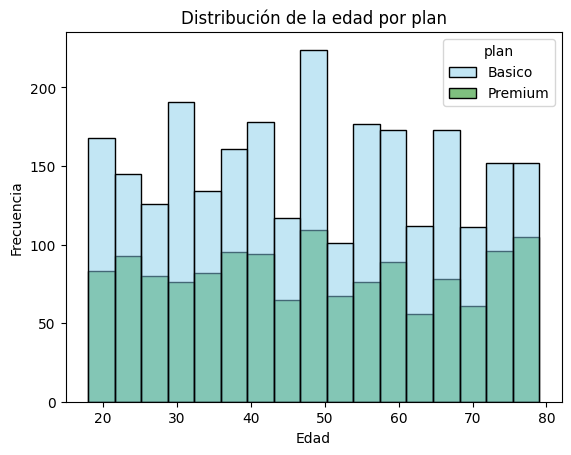

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot( 
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de la edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- No se observa un patrón claro entre la edad de los usuarios y el tipo de plan contratado. Ambos planes presentan una distribución de edades similar y están representados en prácticamente todos los grupos de edad. Aunque el plan Básico registra una mayor frecuencia de usuarios en la mayoría de los intervalos, esto parece estar relacionado con que dicho plan cuenta con más clientes en el conjunto de datos y no con la edad.

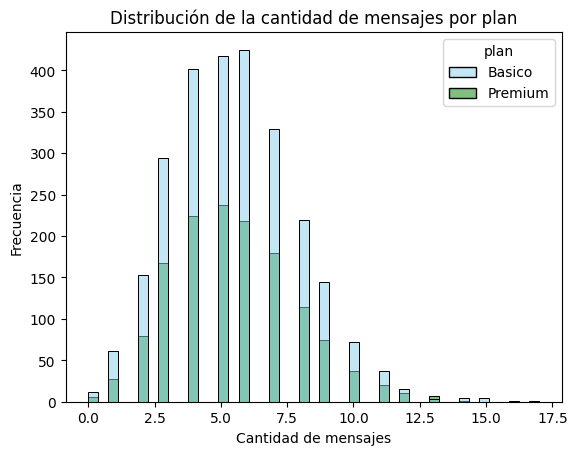

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de la cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- No se identifica un patrón claro entre el tipo de plan y la cantidad de mensajes enviados. La mayoría de los usuarios de ambos planes envía entre 4 y 6 mensajes, mientras que solo una pequeña proporción supera los 10 mensajes. La distribución es sesgada a la derecha, indicando que los usuarios con un alto volumen de mensajes son poco frecuentes.

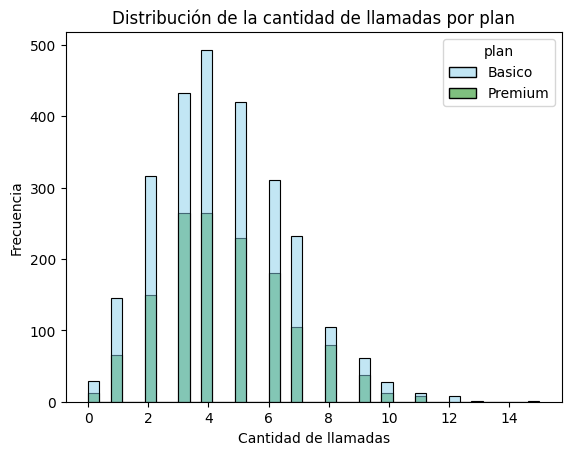

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de la cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- No se identifica un patrón claro entre el tipo de plan y la cantidad de llamadas realizadas. Tanto los usuarios del plan Básico como los del plan Premium concentran la mayor parte de sus llamadas entre 3 y 6, mientras que pocos usuarios realizan más de 8 llamadas. La distribución está sesgada a la derecha, lo que indica que los usuarios con una alta cantidad de llamadas son poco frecuentes.

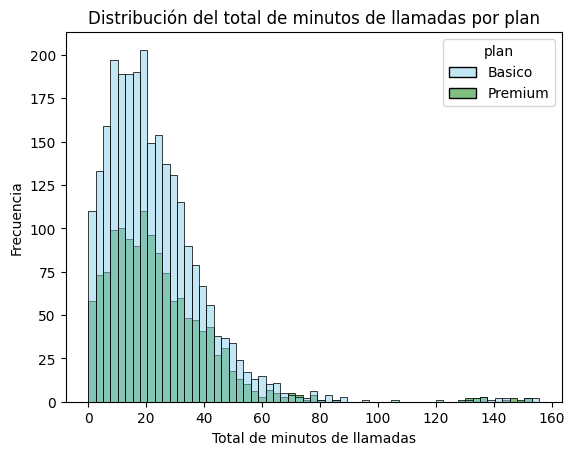

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución del total de minutos de llamadas por plan')
plt.xlabel('Total de minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- No se observa un patrón claro que diferencie el total de minutos de llamadas entre los usuarios de los planes Básico y Premium. En ambos casos, la mayoría de los usuarios acumula entre 5 y 30 minutos de llamadas. No obstante, el plan Premium presenta algunos usuarios con consumos significativamente más altos, lo que podría indicar un uso más intensivo del servicio en un grupo reducido de clientes. La distribución es sesgada a la derecha, ya que pocos usuarios concentran un alto número de minutos de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

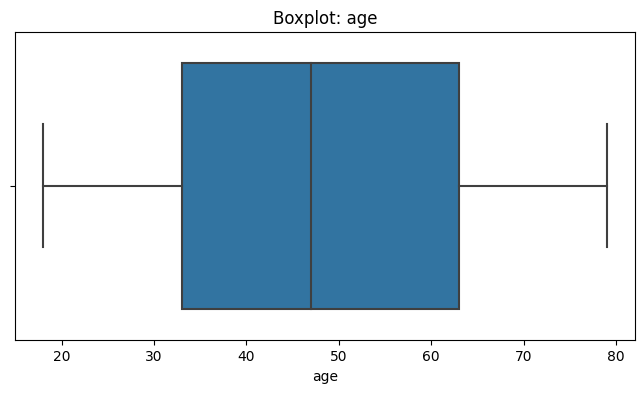

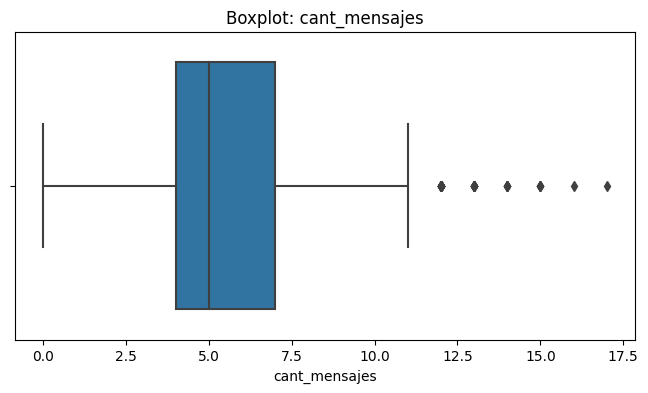

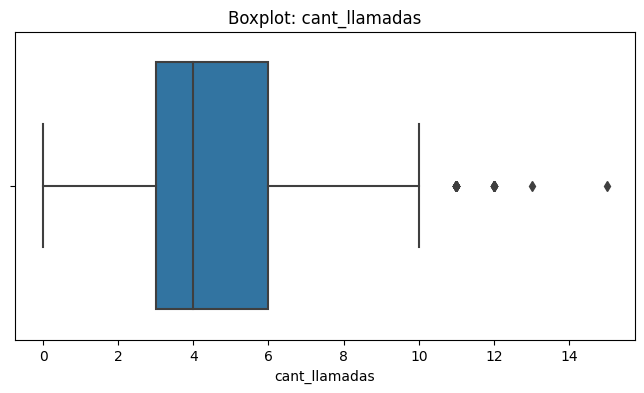

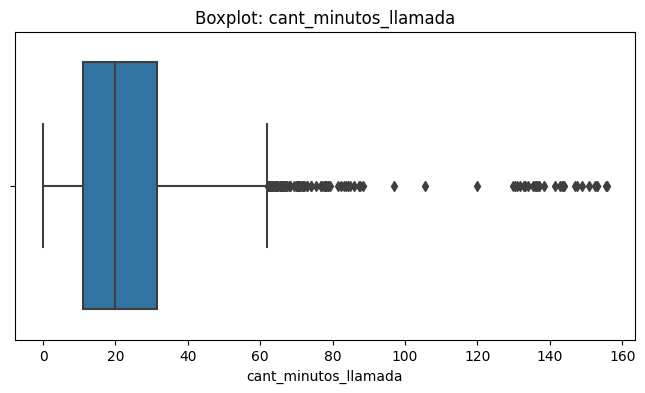

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta valores atípicos (outliers). Todos los registros se encuentran dentro de los límites esperados del diagrama de caja, por lo que no se observan edades inusualmente bajas o altas. La mediana se ubica alrededor de los 47 años, mientras que el 50 % de los usuarios tiene edades aproximadamente entre 34 y 64 años (rango intercuartílico). Además, el rango de edades oscila entre 18 y 79 años, lo que indica que los datos son consistentes y no requieren tratamiento adicional.
  
- cant_mensajes: presenta valores atípicos (outliers) únicamente en el extremo superior de la distribución. La mayoría de los usuarios envía entre 4 y 7 mensajes, con una mediana cercana a 5 mensajes. Sin embargo, se identifican algunos usuarios que envían entre 12 y 17 mensajes, valores que superan el límite superior del boxplot y se consideran atípicos.

  
- cant_llamadas: presenta valores atípicos (outliers) únicamente en el extremo superior de la distribución. La mayoría de los usuarios realiza entre 3 y 6 llamadas, con una mediana cercana a 4 llamadas. Sin embargo, se identifican algunos usuarios que realizan entre 11 y 15 llamadas, valores que exceden el límite superior del boxplot y son considerados atípicos.

  
- cant_minutos_llamada: presenta una cantidad considerable de valores atípicos en el extremo superior de la distribución. La mayoría de los usuarios acumula entre 10 y 30 minutos de llamadas, con una mediana cercana a 20 minutos. Sin embargo, se observa un grupo importante de usuarios que supera los 60 minutos, e incluso algunos alcanzan alrededor de 150 minutos, valores que se consideran outliers según el criterio del boxplot.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Los usuarios envían en promedio 5.5 mensajes, con una mediana de 5, lo que indica que el promedio no está muy influenciado por valores extremos. La mayoría de los usuarios envía entre 4 y 7 mensajes (rango intercuartílico). Aunque existen usuarios que envían hasta 17 mensajes, estos corresponden a outliers superiores que representan un uso intensivo del servicio y no errores en los datos, por lo tanto, se recomienda conservarlos.
- cant_llamadas: En promedio, los usuarios realizan 4.5 llamadas, con una mediana de 4. El 50 % de los usuarios realiza entre 3 y 6 llamadas. Se identifican algunos valores atípicos de hasta 15 llamadas, pero estos reflejan comportamientos reales de usuarios con mayor frecuencia de uso, por lo cual se recomienda conservarlos.
- cant_minutos_llamada: Los usuarios acumulan en promedio 23.3 minutos de llamadas, mientras que la mediana es de 19.8 minutos. El hecho de que la media sea mayor que la mediana indica una asimetría positiva (sesgo hacia la derecha), causada por algunos usuarios con consumos muy elevados. El 50 % de los usuarios acumula entre 11.12 y 31.42 minutos, aunque existen casos que alcanzan 155.69 minutos, considerados outliers superiores, por ende, se recomienda conservarlos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select(
    [
        (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
    ],
    [
        'Bajo uso',
        'Uso medio'
    ],
    default='Alto uso'
)



In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(
    [
        user_profile['age'] < 30,
        user_profile['age'] < 60
    ],
    [
        'Joven',
        'Adulto'
    ],
    default='Adulto Mayor'
)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

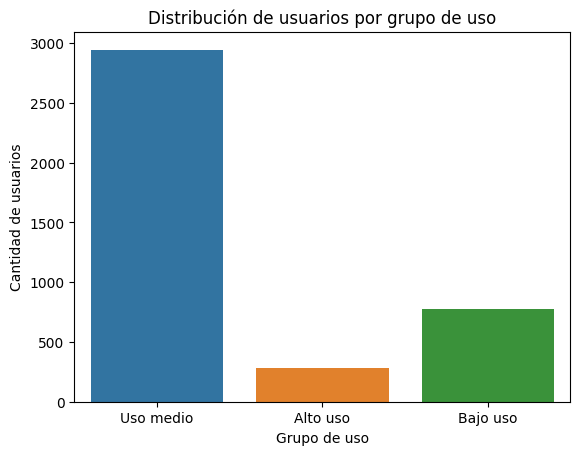

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

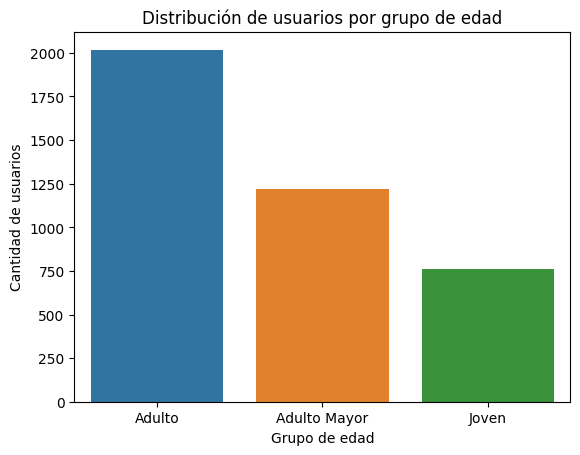

In [44]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Valores nulos en users:
city: 469 valores nulos (11.73%). Se investigó su origen y se recomendó imputarlos o mantenerlos como valores faltantes según el contexto.
churn_date: 3 534 valores nulos (88.35%). Estos valores son esperados, ya que corresponden a usuarios que aún no han cancelado el servicio, por lo que no fue necesario imputarlos ni eliminar la columna.
Valores nulos en usage:
date: 50 valores nulos, los cuales representan un porcentaje muy bajo y pueden imputarse o eliminarse según el caso.
duration: 22 076 valores nulos, pero se comprobó que corresponden exclusivamente a registros de tipo text, por lo que son valores esperados.
length: 17 896 valores nulos, presentes únicamente en registros de tipo call, por lo que también corresponden a la naturaleza de la variable y no representan errores.
Valores inconsistentes:
Se identificaron fechas futuras en reg_date (año 2026), las cuales fueron consideradas inconsistentes y se reemplazaron por valores nulos.
También se revisaron posibles valores centinela, como -999 en la edad y ? en la ciudad, reemplazándolos por valores adecuados.

En general, la mayor parte de los problemas correspondía a valores faltantes esperados por el tipo de registro, más que a errores de calidad de los datos. 


🔍 **Segmentos por Edad**
A partir del análisis se identificaron dos grandes segmentos de clientes:

Usuarios de uso moderado (mayoría):
Edad distribuida entre aproximadamente 18 y 79 años.
Envían entre 4 y 7 mensajes.
Realizan entre 3 y 6 llamadas.
Acumulan entre 11 y 31 minutos de llamadas.
Representan la mayor parte de la base de clientes.
Usuarios de uso intensivo (minoría):
Presentan cantidades significativamente mayores de mensajes, llamadas y minutos.
Constituyen los valores atípicos detectados mediante el método IQR.
Utilizan los servicios con mucha mayor frecuencia que el resto.

Respecto a la edad, no se encontró un patrón claro que relacione la edad con el plan contratado o con un mayor nivel de uso.


📊 **Segmentos por Nivel de Uso**
Los usuarios de uso intensivo parecen ser el segmento más valioso para ConnectaTel porque:

Consumen una mayor cantidad de minutos y realizan más llamadas.
Utilizan con mayor frecuencia los servicios de la compañía.
Representan clientes con mayor potencial de generación de ingresos.
Pueden beneficiarse de planes premium o paquetes con mayores beneficios, favoreciendo su permanencia y satisfacción.

No obstante, el segmento de uso moderado representa la mayor parte de los clientes y constituye la base principal del negocio.


➡️ Se detectaron valores atípicos únicamente en:

Cantidad de mensajes.
Cantidad de llamadas.
Total de minutos de llamadas.

Estos outliers aparecen únicamente en el extremo superior de las distribuciones, indicando usuarios con un consumo considerablemente mayor que el promedio.

Estos registros no representan errores, sino comportamientos reales de clientes con un uso intensivo del servicio.

Para el negocio esto implica que:

Existe un segmento de clientes con necesidades de comunicación superiores al promedio.
Estos usuarios pueden requerir planes especializados con mayores beneficios.
Constituyen una oportunidad para estrategias de fidelización y generación de ingresos adicionales.


💡 **Recomendaciones**
Mantener el plan Básico para usuarios con consumo moderado, quienes representan la mayoría de la base de clientes.
Fortalecer el plan Premium incorporando mayores beneficios para usuarios con alto consumo de llamadas y minutos, incentivando su permanencia.
Diseñar un nuevo plan para usuarios intensivos, que incluya mayores cantidades de minutos y beneficios adicionales, dirigido a quienes presentan los consumos más elevados.
Implementar estrategias de segmentación, utilizando el comportamiento de consumo (mensajes, llamadas y minutos) como criterio para ofrecer promociones y recomendaciones personalizadas.
Realizar monitoreo continuo de los usuarios con alto consumo, ya que representan un segmento estratégico tanto para la generación de ingresos como para el diseño de nuevos productos y servicios. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`